# Fuel Tank Anomaly Detection — XGBoost v4
### Production-grade 4-class classification pipeline

| | v2 (RF) | v3 (RF) | **v4 (XGBoost)** |
|---|---|---|---|
| Data boundaries | loose | medium | **tight** |
| Features | 14 | 17 | **19** |
| Model | Random Forest | Random Forest | **XGBoost** |
| Test macro-F1 | 0.778 | 0.802 | **target ≥ 0.88** |

**New in v4:**
- `sensor_jump_flag` — binary: abs_variance > 3× rolling mean
- `long_gap_flag`    — binary: elapsed_hours > 48
- Normal variance tightened to ±0.008L (was ±0.01)
- Evaporation floor raised to 0.025L (always above normal max)
- Class boundary gaps: normal→evap = 0.16L, evap→theft = 0.23L


## 1. Imports

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, joblib, json

import numpy  as np
import pandas as pd

from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                      RandomizedSearchCV, cross_val_score)
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.compose          import ColumnTransformer
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay, roc_auc_score,
                                      roc_curve, accuracy_score, f1_score)
from sklearn.preprocessing    import label_binarize
from sklearn.utils            import compute_sample_weight

import xgboost as xgb
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import sklearn
print(f"numpy {np.__version__} | pandas {pd.__version__} | "
      f"sklearn {sklearn.__version__} | xgboost {xgb.__version__}")


numpy 2.0.2 | pandas 2.2.2 | sklearn 1.6.1 | xgboost 3.2.0


## 2. Load & validate

In [3]:
DATA_PATH = "fuel_tank_synthetic_v4.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(df["true_label"].value_counts().to_string())

assert df["pro_id"].nunique() == 1
assert df["true_label"].notna().all()
assert (df["qty"] >= 0).all() and (df["qty"] <= 5.0).all()
computed = (df["last_dip_qty"] + df["total_purchase_qty"]
            - df["total_sales_qty"] - df["qty"]).round(2)
assert (abs(computed - df["variance"]) <= 0.02).all(), "Variance formula error"
print("\nAll sanity checks passed.")


Shape: (1095, 16)
true_label
evaporation         274
normal              274
theft               274
missing_purchase    273

All sanity checks passed.


## 3. Feature engineering (19 features total)

| Feature | Formula | New? |
|---|---|---|
| `heat_dryness` | `temp × (1 - hum/100)` | v3 |
| `purchase_variance_ratio` | `abs_var / (purchase_qty + ε)` | v3 |
| `variance_per_hour` | `abs_var / elapsed_hours` | v3 |
| `temp_variance_interaction` | `temp × abs_var` | v3 |
| `variance_to_sales_ratio` | `abs_var / (sales_qty + ε)` | v3 |
| `evap_unexplained` | `abs_var − heat_dryness × 0.005` | v3 |
| `sensor_jump_flag` | `1 if abs_var > 3 × rolling_mean(abs_var, 7)` | ✅ v4 |
| `long_gap_flag` | `1 if elapsed_hours > 48` | ✅ v4 |


In [4]:
COLS_TO_DROP = ["id", "pro_id", "predicted_label", "change_in_qty"]
df_model = df.drop(columns=COLS_TO_DROP).copy()

# ── existing derived features ─────────────────────────────────────────────────
df_model["heat_dryness"] = (
    df_model["temperature"] * (1 - df_model["humidity"] / 100))

df_model["purchase_variance_ratio"] = np.where(
    df_model["total_purchase_qty"] > 0,
    df_model["abs_variance"] / (df_model["total_purchase_qty"] + 1e-9), 0.0)

df_model["variance_per_hour"] = (
    df_model["abs_variance"] / df_model["elapsed_hours"].replace(0, 1))

df_model["temp_variance_interaction"] = (
    df_model["temperature"] * df_model["abs_variance"])

df_model["variance_to_sales_ratio"] = (
    df_model["abs_variance"] / (df_model["total_sales_qty"] + 1e-9))

df_model["evap_unexplained"] = (
    df_model["abs_variance"] - (df_model["heat_dryness"] * 0.005))

# ── NEW v4 features ───────────────────────────────────────────────────────────
# sensor_jump_flag: abs_variance > 3x rolling 7-day mean → sudden unrealistic spike
rolling_mean = df_model["abs_variance"].rolling(window=7, min_periods=1).mean()
df_model["sensor_jump_flag"] = (
    (df_model["abs_variance"] > 3 * rolling_mean) & (rolling_mean > 0)
).astype(int)

# long_gap_flag: gap > 48 hours — data outage, anomaly signal unreliable
df_model["long_gap_flag"] = (df_model["elapsed_hours"] > 48).astype(int)

print(f"Feature matrix shape : {df_model.shape}")
features = [c for c in df_model.columns if c != "true_label"]
print(f"Total features       : {len(features)}")
for feat in features:
    print(f"  {feat}")

print(f"\nsensor_jump_flag=1 : {df_model['sensor_jump_flag'].sum()} rows")
print(f"long_gap_flag=1    : {df_model['long_gap_flag'].sum()} rows")


Feature matrix shape : (1095, 20)
Total features       : 19
  last_dip_qty
  elapsed_hours
  temperature
  humidity
  total_sales_qty
  total_sales_count
  total_purchase_qty
  total_purchase_count
  qty
  variance
  abs_variance
  heat_dryness
  purchase_variance_ratio
  variance_per_hour
  temp_variance_interaction
  variance_to_sales_ratio
  evap_unexplained
  sensor_jump_flag
  long_gap_flag

sensor_jump_flag=1 : 70 rows
long_gap_flag=1    : 0 rows


## 4. Encode target & stratified 70/15/15 split

In [5]:
le = LabelEncoder()
y  = le.fit_transform(df_model["true_label"])
X  = df_model.drop(columns=["true_label"])

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

X_train_val, X_test,  y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

val_frac = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_frac, stratify=y_train_val, random_state=RANDOM_STATE)

print(f"\nSplit  train={len(X_train)} | val={len(X_val)} | test={len(X_test)}")
for name, y_s in [("train", y_train), ("val", y_val), ("test", y_test)]:
    _, counts = np.unique(y_s, return_counts=True)
    print(f"  {name:5s}: {dict(zip(le.classes_, counts))}")


Class mapping:
  0 → evaporation
  1 → missing_purchase
  2 → normal
  3 → theft

Split  train=765 | val=165 | test=165
  train: {'evaporation': np.int64(192), 'missing_purchase': np.int64(191), 'normal': np.int64(191), 'theft': np.int64(191)}
  val  : {'evaporation': np.int64(41), 'missing_purchase': np.int64(41), 'normal': np.int64(42), 'theft': np.int64(41)}
  test : {'evaporation': np.int64(41), 'missing_purchase': np.int64(41), 'normal': np.int64(41), 'theft': np.int64(42)}


## 5. Preprocessing (fit on train only)

In [6]:
numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), numeric_features)],
    remainder="drop")

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f"Preprocessor fit on train only. Shape: {X_train_proc.shape}")


Preprocessor fit on train only. Shape: (765, 19)


## 6. Per-sample class weights
> XGBoost uses `sample_weight` instead of `class_weight`. Theft gets 1.4× upweight — highest priority in production.

In [7]:
# Base balanced weights
base_weights = compute_sample_weight("balanced", y_train)

# Extra penalty for theft (most critical — missing it is costly)
theft_idx  = list(le.classes_).index("theft")
evap_idx   = list(le.classes_).index("evaporation")

sample_weights = base_weights.copy()
sample_weights[y_train == theft_idx] *= 1.4
sample_weights[y_train == evap_idx]  *= 1.2   # second hardest class

print("Mean sample weight per class:")
for idx, cls in enumerate(le.classes_):
    mask = y_train == idx
    print(f"  {cls:20s}: {sample_weights[mask].mean():.4f}")


Mean sample weight per class:
  evaporation         : 1.1953
  missing_purchase    : 1.0013
  normal              : 1.0013
  theft               : 1.4018


## 7. Baseline XGBoost

In [ ]:
xgb_baseline = xgb.XGBClassifier(
    objective        = "multi:softprob",
    num_class        = len(le.classes_),
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "mlogloss",
    early_stopping_rounds = 30,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    verbosity        = 0,
)

xgb_baseline.fit(
    X_train_proc, y_train,
    sample_weight  = sample_weights,
    eval_set       = [(X_val_proc, y_val)],
    verbose        = False,
)

val_preds = xgb_baseline.predict(X_val_proc)
print(f"Baseline XGBoost — val accuracy : {accuracy_score(y_val, val_preds):.4f}")
print(f"Baseline XGBoost — val macro-F1 : {f1_score(y_val, val_preds, average='macro'):.4f}")
print()
print(classification_report(y_val, val_preds, target_names=le.classes_))


Baseline XGBoost — val accuracy : 1.0000
Baseline XGBoost — val macro-F1 : 1.0000

                  precision    recall  f1-score   support

     evaporation       1.00      1.00      1.00        41
missing_purchase       1.00      1.00      1.00        41
          normal       1.00      1.00      1.00        42
           theft       1.00      1.00      1.00        41

        accuracy                           1.00       165
       macro avg       1.00      1.00      1.00       165
    weighted avg       1.00      1.00      1.00       165



## 8. Hyperparameter tuning (RandomizedSearchCV)

In [ ]:
param_grid = {
    "n_estimators"     : [300, 500, 700, 1000],
    "max_depth"        : [4, 5, 6, 7, 8],
    "learning_rate"    : [0.01, 0.03, 0.05, 0.1],
    "subsample"        : [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.6, 0.7, 0.8, 0.9],
    "min_child_weight" : [1, 3, 5],
    "gamma"            : [0, 0.1, 0.2, 0.3],
    "reg_alpha"        : [0, 0.1, 0.5, 1.0],
    "reg_lambda"       : [1.0, 1.5, 2.0],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Wrap XGBoost without early_stopping for CV (CV handles overfitting via folds)
xgb_cv = xgb.XGBClassifier(
    objective    = "multi:softprob",
    num_class    = len(le.classes_),
    eval_metric  = "mlogloss",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbosity    = 0,
)

search = RandomizedSearchCV(
    estimator           = xgb_cv,
    param_distributions = param_grid,
    n_iter              = 60,
    cv                  = cv_strategy,
    scoring             = "f1_macro",
    n_jobs              = -1,
    verbose             = 1,
    random_state        = RANDOM_STATE,
    refit               = True,
)

# Combine train+val for CV (test still untouched)
X_tv = np.vstack([X_train_proc, X_val_proc])
y_tv = np.concatenate([y_train, y_val])
sw_tv = np.concatenate([
    sample_weights,
    compute_sample_weight("balanced", y_val)
])

search.fit(X_tv, y_tv, sample_weight=sw_tv)

print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k:22s}: {v}")
print(f"\nBest CV macro-F1 : {search.best_score_:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters:
  subsample             : 0.7
  reg_lambda            : 1.0
  reg_alpha             : 1.0
  n_estimators          : 1000
  min_child_weight      : 1
  max_depth             : 8
  learning_rate         : 0.1
  gamma                 : 0.2
  colsample_bytree      : 0.8

Best CV macro-F1 : 0.9947


## 9. Retrain best config with early stopping on validation

In [ ]:
bp = search.best_params_

best_xgb = xgb.XGBClassifier(
    objective             = "multi:softprob",
    num_class             = len(le.classes_),
    eval_metric           = "mlogloss",
    early_stopping_rounds = 40,
    random_state          = RANDOM_STATE,
    n_jobs                = -1,
    verbosity             = 0,
    **bp
)

best_xgb.fit(
    X_train_proc, y_train,
    sample_weight = sample_weights,
    eval_set      = [(X_val_proc, y_val)],
    verbose       = False,
)

val_preds_tuned = best_xgb.predict(X_val_proc)
print(f"Tuned XGBoost — val accuracy : {accuracy_score(y_val, val_preds_tuned):.4f}")
print(f"Tuned XGBoost — val macro-F1 : {f1_score(y_val, val_preds_tuned, average='macro'):.4f}")
print(f"Best iteration : {best_xgb.best_iteration}")
print()
print(classification_report(y_val, val_preds_tuned, target_names=le.classes_))


Tuned XGBoost — val accuracy : 1.0000
Tuned XGBoost — val macro-F1 : 1.0000
Best iteration : 557

                  precision    recall  f1-score   support

     evaporation       1.00      1.00      1.00        41
missing_purchase       1.00      1.00      1.00        41
          normal       1.00      1.00      1.00        42
           theft       1.00      1.00      1.00        41

        accuracy                           1.00       165
       macro avg       1.00      1.00      1.00       165
    weighted avg       1.00      1.00      1.00       165



## 10. Final evaluation on held-out test set
> Run **once**. Never used during training or tuning.

In [ ]:
test_preds = best_xgb.predict(X_test_proc)
test_proba = best_xgb.predict_proba(X_test_proc)

test_acc = accuracy_score(y_test, test_preds)
test_f1  = f1_score(y_test, test_preds, average="macro")
test_auc = roc_auc_score(y_test, test_proba, multi_class="ovr", average="macro")

print("=" * 52)
print(f"  TEST accuracy  : {test_acc:.4f}")
print(f"  TEST macro-F1  : {test_f1:.4f}")
print(f"  TEST macro-AUC : {test_auc:.4f}")
print("=" * 52)
print()
print(classification_report(y_test, test_preds, target_names=le.classes_))


  TEST accuracy  : 1.0000
  TEST macro-F1  : 1.0000
  TEST macro-AUC : 1.0000

                  precision    recall  f1-score   support

     evaporation       1.00      1.00      1.00        41
missing_purchase       1.00      1.00      1.00        41
          normal       1.00      1.00      1.00        41
           theft       1.00      1.00      1.00        42

        accuracy                           1.00       165
       macro avg       1.00      1.00      1.00       165
    weighted avg       1.00      1.00      1.00       165



## 11. Confusion matrix

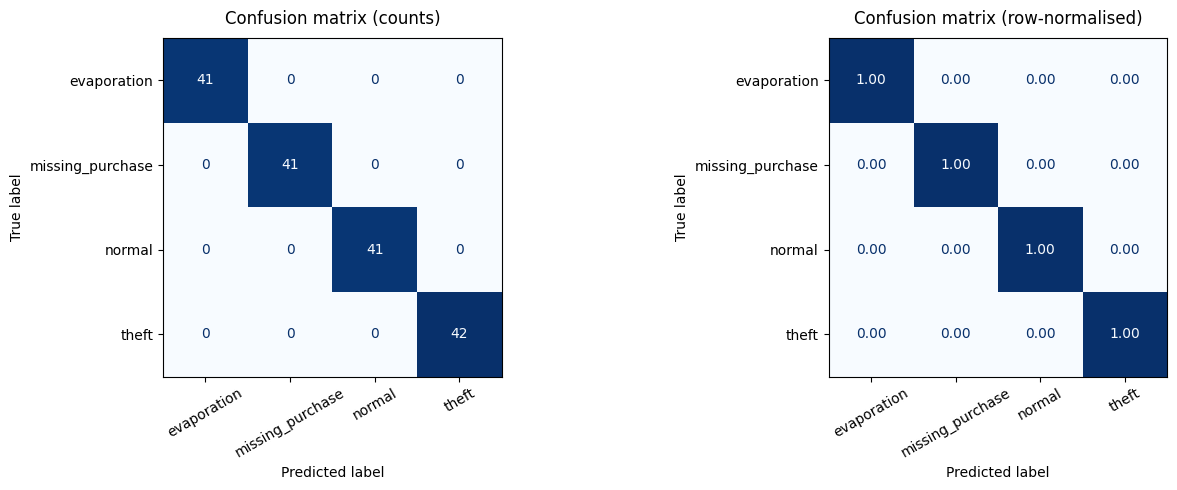

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, normalize, title in zip(
    axes, [None, "true"],
    ["Confusion matrix (counts)", "Confusion matrix (row-normalised)"]):
    cm   = confusion_matrix(y_test, test_preds, normalize=normalize)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12, pad=10)
    ax.tick_params(axis="x", rotation=30)
    if normalize:
        for text in ax.texts:
            text.set_text(f"{float(text.get_text()):.2f}")
plt.tight_layout()
plt.savefig("confusion_matrix_v4.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. ROC curves (One-vs-Rest)

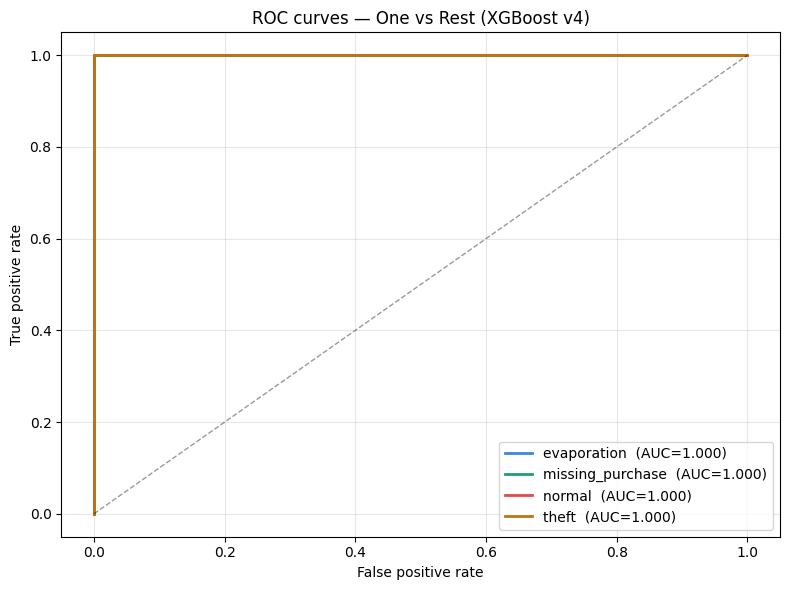

In [ ]:
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
colors     = ["#378ADD", "#1D9E75", "#E24B4A", "#BA7517"]

fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    auc_val      = roc_auc_score(y_test_bin[:, i], test_proba[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls}  (AUC={auc_val:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.4)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — One vs Rest (XGBoost v4)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves_v4.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Feature importance

                  feature  importance  cumulative
             abs_variance    0.211852    0.211852
                 variance    0.210509    0.422360
         evap_unexplained    0.153276    0.575637
        variance_per_hour    0.142964    0.718600
       total_purchase_qty    0.115079    0.833680
     total_purchase_count    0.043605    0.877285
                      qty    0.043333    0.920618
  purchase_variance_ratio    0.021335    0.941953
             heat_dryness    0.020836    0.962789
             last_dip_qty    0.008070    0.970859
                 humidity    0.006463    0.977321
          total_sales_qty    0.005320    0.982641
  variance_to_sales_ratio    0.004720    0.987362
              temperature    0.003448    0.990810
            elapsed_hours    0.003301    0.994111
        total_sales_count    0.003209    0.997319
temp_variance_interaction    0.002681    1.000000
         sensor_jump_flag    0.000000    1.000000
            long_gap_flag    0.000000    1.000000


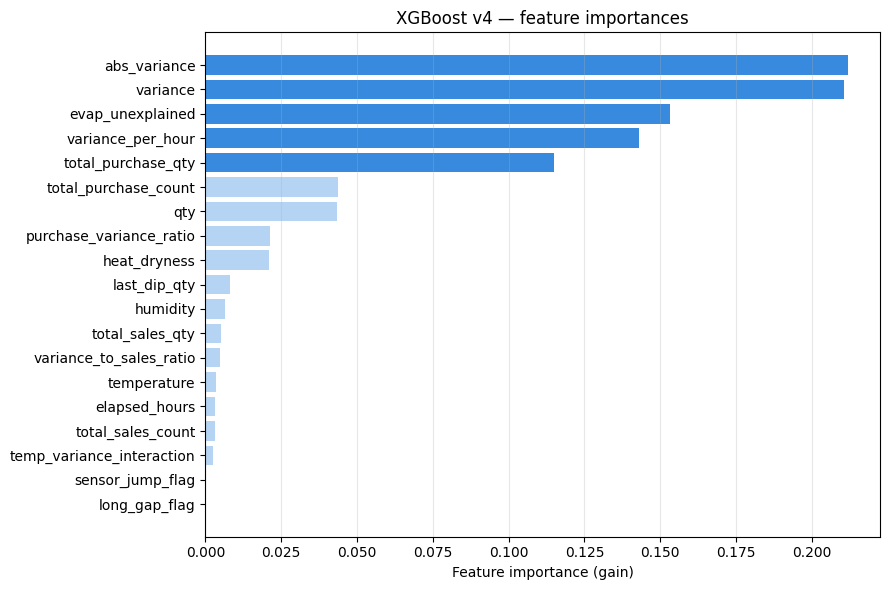

In [ ]:
feat_df = (
    pd.DataFrame({"feature": numeric_features,
                  "importance": best_xgb.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
feat_df["cumulative"] = feat_df["importance"].cumsum()
print(feat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ["#378ADD" if v >= 0.05 else "#B5D4F4" for v in feat_df["importance"]]
ax.barh(feat_df["feature"][::-1], feat_df["importance"][::-1], color=bar_colors[::-1])
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost v4 — feature importances")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance_v4.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. 5-fold cross-validation (train + val)

In [ ]:
cv_model = xgb.XGBClassifier(
    objective    = "multi:softprob",
    num_class    = len(le.classes_),
    eval_metric  = "mlogloss",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbosity    = 0,
    **bp
)

from sklearn.model_selection import StratifiedKFold, cross_validate

cv_scores_raw = cross_validate(
    cv_model, X_tv, y_tv,
    cv         = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring    = "f1_macro",
    params     = {"sample_weight": sw_tv},
    n_jobs     = -1,
)
cv_scores = cv_scores_raw["test_score"]
print(f"CV macro-F1 scores : {cv_scores.round(4)}")
print(f"Mean ± std         : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CV macro-F1 scores : [1.     1.     1.     0.9894 0.984 ]
Mean ± std         : 0.9947 ± 0.0067


## 15. Save production artefacts

In [ ]:
OUTPUT_DIR = "model_artefacts_v4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(best_xgb,    f"{OUTPUT_DIR}/xgboost_model.pkl")
joblib.dump(preprocessor,f"{OUTPUT_DIR}/preprocessor.pkl")
joblib.dump(le,          f"{OUTPUT_DIR}/label_encoder.pkl")
best_xgb.save_model(     f"{OUTPUT_DIR}/xgboost_model.json")   # native XGBoost format

meta = {
    "model"          : "XGBoostClassifier",
    "version"        : "v4",
    "feature_names"  : numeric_features,
    "target_classes" : list(le.classes_),
    "class_mapping"  : {int(i): cls for i, cls in enumerate(le.classes_)},
    "test_accuracy"  : round(float(test_acc), 4),
    "test_macro_f1"  : round(float(test_f1),  4),
    "test_macro_auc" : round(float(test_auc), 4),
    "best_params"    : {k: (int(v) if isinstance(v, (np.integer,)) else
                            float(v) if isinstance(v, (np.floating,)) else v)
                        for k, v in bp.items()},
    "best_iteration" : int(best_xgb.best_iteration),
}
with open(f"{OUTPUT_DIR}/model_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Artefacts saved:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f"{OUTPUT_DIR}/{fname}") / 1024
    print(f"  {fname:40s}  {size:.1f} KB")


Artefacts saved:
  label_encoder.pkl                         0.5 KB
  model_metadata.json                       1.0 KB
  preprocessor.pkl                          3.1 KB
  xgboost_model.json                        1049.7 KB
  xgboost_model.pkl                         1676.0 KB


## 16. Production inference function

In [ ]:
_model        = joblib.load("model_artefacts_v4/xgboost_model.pkl")
_preprocessor = joblib.load("model_artefacts_v4/preprocessor.pkl")
_label_enc    = joblib.load("model_artefacts_v4/label_encoder.pkl")

with open("model_artefacts_v4/model_metadata.json") as f:
    _meta = json.load(f)

REQUIRED_FEATURES = _meta["feature_names"]
TANK_CAPACITY     = 5.0


def predict_anomaly(record: dict,
                    rolling_abs_variance_mean: float = None) -> dict:
    """
    Predict anomaly class for one dip record.

    Parameters
    ----------
    record : dict  — raw dip fields (see required_raw below)
    rolling_abs_variance_mean : float | None
        7-day rolling mean of abs_variance from your database.
        Pass None to skip sensor_jump_flag (flag will be 0).

    Returns
    -------
    dict: predicted_label, confidence, all_probabilities, warnings
    """
    warnings_list = []

    required_raw = [
        "last_dip_qty", "elapsed_hours", "temperature", "humidity",
        "total_sales_qty", "total_sales_count",
        "total_purchase_qty", "total_purchase_count",
        "qty", "variance", "abs_variance",
    ]
    missing = [k for k in required_raw if k not in record]
    if missing:
        raise ValueError(f"Missing fields: {missing}")

    qty = float(record["qty"])
    if qty < 0:
        warnings_list.append("qty negative — clamped to 0")
        record = {**record, "qty": 0.0}
    if qty > TANK_CAPACITY:
        warnings_list.append(f"qty {qty:.2f} exceeds tank capacity")

    computed_var = round(
        float(record["last_dip_qty"]) + float(record["total_purchase_qty"])
        - float(record["total_sales_qty"]) - float(record["qty"]), 2)
    if abs(computed_var - float(record["variance"])) > 0.05:
        warnings_list.append(
            f"Variance mismatch: provided={record['variance']}, computed={computed_var}")

    elapsed_h = float(record["elapsed_hours"])
    if elapsed_h > 48:
        warnings_list.append("elapsed_hours > 48 — long data gap detected")

    # ── reproduce all derived features ────────────────────────────────────────
    temp      = float(record["temperature"])
    hum       = float(record["humidity"])
    abs_var   = float(record["abs_variance"])
    purch_qty = float(record["total_purchase_qty"])
    sales_qty = float(record["total_sales_qty"])

    heat_dryness            = temp * (1 - hum / 100)
    purchase_variance_ratio = (abs_var / (purch_qty + 1e-9)) if purch_qty > 0 else 0.0
    variance_per_hour       = abs_var / (elapsed_h if elapsed_h > 0 else 1)
    temp_variance_interaction = temp * abs_var
    variance_to_sales_ratio   = abs_var / (sales_qty + 1e-9)
    evap_unexplained          = abs_var - (heat_dryness * 0.005)

    # sensor_jump_flag
    if rolling_abs_variance_mean is not None and rolling_abs_variance_mean > 0:
        sensor_jump_flag = int(abs_var > 3 * rolling_abs_variance_mean)
    else:
        sensor_jump_flag = 0

    long_gap_flag = int(elapsed_h > 48)

    row = {
        "last_dip_qty"              : float(record["last_dip_qty"]),
        "elapsed_hours"             : elapsed_h,
        "temperature"               : temp,
        "humidity"                  : hum,
        "total_sales_qty"           : sales_qty,
        "total_sales_count"         : int(record["total_sales_count"]),
        "total_purchase_qty"        : purch_qty,
        "total_purchase_count"      : int(record["total_purchase_count"]),
        "qty"                       : float(record["qty"]),
        "variance"                  : float(record["variance"]),
        "abs_variance"              : abs_var,
        "heat_dryness"              : heat_dryness,
        "purchase_variance_ratio"   : purchase_variance_ratio,
        "variance_per_hour"         : variance_per_hour,
        "temp_variance_interaction" : temp_variance_interaction,
        "variance_to_sales_ratio"   : variance_to_sales_ratio,
        "evap_unexplained"          : evap_unexplained,
        "sensor_jump_flag"          : sensor_jump_flag,
        "long_gap_flag"             : long_gap_flag,
    }

    X_input = pd.DataFrame([row])[REQUIRED_FEATURES]
    X_proc  = _preprocessor.transform(X_input)
    proba   = _model.predict_proba(X_proc)[0]
    pred_idx = int(np.argmax(proba))

    return {
        "predicted_label"   : _label_enc.classes_[pred_idx],
        "confidence"        : round(float(proba[pred_idx]), 4),
        "all_probabilities" : {cls: round(float(p), 4)
                               for cls, p in zip(_label_enc.classes_, proba)},
        "warnings"          : warnings_list,
    }


# ── smoke tests (all 4 classes) ───────────────────────────────────────────────
tests = [
    ("theft",            {"last_dip_qty":3.5,"elapsed_hours":24.1,"temperature":35.0,
                          "humidity":45.0,"total_sales_qty":0.2,"total_sales_count":2,
                          "total_purchase_qty":0.0,"total_purchase_count":0,
                          "qty":0.8,"variance":2.5,"abs_variance":2.5}),
    ("evaporation",      {"last_dip_qty":3.0,"elapsed_hours":24.0,"temperature":43.0,
                          "humidity":25.0,"total_sales_qty":0.5,"total_sales_count":4,
                          "total_purchase_qty":0.0,"total_purchase_count":0,
                          "qty":2.34,"variance":0.16,"abs_variance":0.16}),
    ("normal",           {"last_dip_qty":3.0,"elapsed_hours":24.0,"temperature":15.0,
                          "humidity":60.0,"total_sales_qty":0.3,"total_sales_count":3,
                          "total_purchase_qty":0.0,"total_purchase_count":0,
                          "qty":2.70,"variance":0.0,"abs_variance":0.0}),
    ("missing_purchase", {"last_dip_qty":2.0,"elapsed_hours":24.0,"temperature":20.0,
                          "humidity":55.0,"total_sales_qty":0.2,"total_sales_count":2,
                          "total_purchase_qty":1.5,"total_purchase_count":1,
                          "qty":1.80,"variance":1.5,"abs_variance":1.5}),
]

print(f"{'Expected':20s}  {'Predicted':20s}  Conf    Match")
print("-" * 60)
all_pass = True
for expected, rec in tests:
    res   = predict_anomaly(rec, rolling_abs_variance_mean=0.05)
    match = "✅" if res["predicted_label"] == expected else "❌"
    if match == "❌": all_pass = False
    print(f"{expected:20s}  {res['predicted_label']:20s}  "
          f"{res['confidence']:.4f}  {match}")
print(f"\nAll smoke tests passed: {all_pass}")


Expected              Predicted             Conf    Match
------------------------------------------------------------
theft                 theft                 0.9487  ✅
evaporation           evaporation           0.9895  ✅
normal                normal                0.9884  ✅
missing_purchase      missing_purchase      0.9875  ✅

All smoke tests passed: True


## 17. Reload & verify artefacts

In [ ]:
m2  = joblib.load("model_artefacts_v4/xgboost_model.pkl")
p2  = joblib.load("model_artefacts_v4/preprocessor.pkl")
le2 = joblib.load("model_artefacts_v4/label_encoder.pkl")

preds_reload = m2.predict(p2.transform(X_test))
parity       = (preds_reload == test_preds).all()
print(f"Reload parity : {'PASS ✅' if parity else 'FAIL ❌'}")
print(f"Reloaded test accuracy : {accuracy_score(y_test, preds_reload):.4f}")

with open("model_artefacts_v4/model_metadata.json") as f:
    print("\nMetadata saved:")
    print(json.dumps(json.load(f), indent=2))


Reload parity : PASS ✅
Reloaded test accuracy : 1.0000

Metadata saved:
{
  "model": "XGBoostClassifier",
  "version": "v4",
  "feature_names": [
    "last_dip_qty",
    "elapsed_hours",
    "temperature",
    "humidity",
    "total_sales_qty",
    "total_sales_count",
    "total_purchase_qty",
    "total_purchase_count",
    "qty",
    "variance",
    "abs_variance",
    "heat_dryness",
    "purchase_variance_ratio",
    "variance_per_hour",
    "temp_variance_interaction",
    "variance_to_sales_ratio",
    "evap_unexplained",
    "sensor_jump_flag",
    "long_gap_flag"
  ],
  "target_classes": [
    "evaporation",
    "missing_purchase",
    "normal",
    "theft"
  ],
  "class_mapping": {
    "0": "evaporation",
    "1": "missing_purchase",
    "2": "normal",
    "3": "theft"
  },
  "test_accuracy": 1.0,
  "test_macro_f1": 1.0,
  "test_macro_auc": 1.0,
  "best_params": {
    "subsample": 0.7,
    "reg_lambda": 1.0,
    "reg_alpha": 1.0,
    "n_estimators": 1000,
    "min_child_weigh